# Reamostragem e pesos de classe

**Tema:** Preparação de Dados › Dados Desbalanceados

Este notebook implementa, do zero, random undersampling, random
oversampling e SMOTE — e compara os três com a alternativa de pesos de
classe. O ponto central: toda reamostragem acontece **só no treino**, e a
avaliação é sempre feita na distribuição real (desbalanceada) do teste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.neighbors import NearestNeighbors

rng = np.random.default_rng(12)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O mesmo dataset de fraude do notebook anterior

In [2]:
n = 8000
taxa_fraude = 0.03
n_fraude = int(n * taxa_fraude)
n_legitima = n - n_fraude

media_legitima, media_fraude = [90, 13], [130, 9]
cov = [[900, 0], [0, 16]]
X_legitima = rng.multivariate_normal(media_legitima, cov, n_legitima)
X_fraude = rng.multivariate_normal(media_fraude, cov, n_fraude)

X = np.vstack([X_legitima, X_fraude])
y = np.concatenate([np.zeros(n_legitima), np.ones(n_fraude)])
ordem = rng.permutation(n)
X, y = X[ordem], y[ordem]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)
print(f"treino: {len(y_treino)} ({y_treino.mean():.2%} fraude)")
print(f"teste : {len(y_teste)} ({y_teste.mean():.2%} fraude)  <- NUNCA reamostrado")

treino: 5600 (3.00% fraude)
teste : 2400 (3.00% fraude)  <- NUNCA reamostrado


## 2. Random undersampling: descartando exemplos da classe majoritária

In [3]:
def random_undersample(X, y, seed=0):
    rng_local = np.random.default_rng(seed)
    idx_min = np.where(y == 1)[0]
    idx_maj = np.where(y == 0)[0]
    idx_maj_reduzido = rng_local.choice(idx_maj, size=len(idx_min), replace=False)
    idx_final = np.concatenate([idx_min, idx_maj_reduzido])
    rng_local.shuffle(idx_final)
    return X[idx_final], y[idx_final]


X_under, y_under = random_undersample(X_treino, y_treino)
print(f"antes do undersampling: {len(y_treino)} linhas, {y_treino.mean():.2%} fraude")
print(f"depois do undersampling: {len(y_under)} linhas, {y_under.mean():.2%} fraude")

antes do undersampling: 5600 linhas, 3.00% fraude
depois do undersampling: 336 linhas, 50.00% fraude


## 3. Random oversampling: duplicando exemplos da classe minoritária

In [4]:
def random_oversample(X, y, seed=0):
    rng_local = np.random.default_rng(seed)
    idx_min = np.where(y == 1)[0]
    idx_maj = np.where(y == 0)[0]
    idx_min_ampliado = rng_local.choice(idx_min, size=len(idx_maj), replace=True)
    idx_final = np.concatenate([idx_min_ampliado, idx_maj])
    rng_local.shuffle(idx_final)
    return X[idx_final], y[idx_final]


X_over, y_over = random_oversample(X_treino, y_treino)
print(f"antes do oversampling : {len(y_treino)} linhas, {y_treino.mean():.2%} fraude")
print(f"depois do oversampling: {len(y_over)} linhas, {y_over.mean():.2%} fraude")
print(f"\nexemplos ÚNICOS de fraude no treino original: {(y_treino==1).sum()}")
print(f"exemplos de fraude após oversampling (com repetição): {(y_over==1).sum()}")

antes do oversampling : 5600 linhas, 3.00% fraude
depois do oversampling: 10864 linhas, 50.00% fraude

exemplos ÚNICOS de fraude no treino original: 168
exemplos de fraude após oversampling (com repetição): 5432


## 4. SMOTE do zero: interpolando entre vizinhos da classe minoritária

In [5]:
def smote(X, y, n_vizinhos=5, seed=0):
    """SMOTE simplificado: gera sintéticos até equilibrar as classes."""
    rng_local = np.random.default_rng(seed)
    X_min = X[y == 1]
    n_maj = (y == 0).sum()
    n_sinteticos = n_maj - len(X_min)

    vizinhos = NearestNeighbors(n_neighbors=n_vizinhos + 1).fit(X_min)
    _, indices_vizinhos = vizinhos.kneighbors(X_min)

    sinteticos = []
    for _ in range(n_sinteticos):
        i = rng_local.integers(0, len(X_min))
        # exclui o próprio ponto (sempre o vizinho mais próximo de si mesmo)
        vizinho_escolhido = rng_local.choice(indices_vizinhos[i, 1:])
        lam = rng_local.uniform(0, 1)
        novo_ponto = X_min[i] + lam * (X_min[vizinho_escolhido] - X_min[i])
        sinteticos.append(novo_ponto)

    X_sintetico = np.array(sinteticos)
    X_final = np.vstack([X, X_sintetico])
    y_final = np.concatenate([y, np.ones(len(X_sintetico))])
    idx = rng_local.permutation(len(y_final))
    return X_final[idx], y_final[idx]


X_smote, y_smote = smote(X_treino, y_treino)
print(f"antes do SMOTE : {len(y_treino)} linhas, {(y_treino==1).sum()} fraudes")
print(f"depois do SMOTE: {len(y_smote)} linhas, {(y_smote==1).sum():.0f} fraudes "
      f"(originais + sintéticas)")

antes do SMOTE : 5600 linhas, 168 fraudes
depois do SMOTE: 10864 linhas, 5432 fraudes (originais + sintéticas)


## 5. Visualizando os três: original, oversample, SMOTE

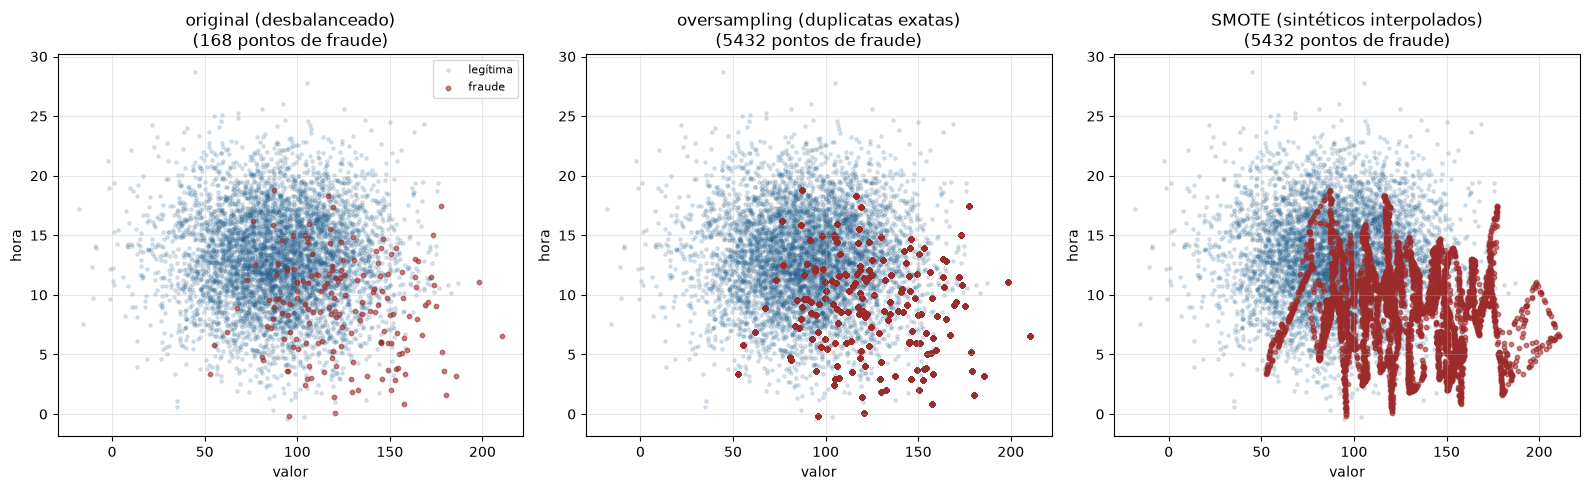

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (Xd, yd, nome) in zip(axes, [
    (X_treino, y_treino, "original (desbalanceado)"),
    (X_over, y_over, "oversampling (duplicatas exatas)"),
    (X_smote, y_smote, "SMOTE (sintéticos interpolados)"),
]):
    ax.scatter(Xd[yd == 0, 0], Xd[yd == 0, 1], s=6, alpha=0.15, color=AZUL, label="legítima")
    ax.scatter(Xd[yd == 1, 0], Xd[yd == 1, 1], s=10, alpha=0.6, color=VERMELHO, label="fraude")
    ax.set_title(f"{nome}\n({int((yd==1).sum())} pontos de fraude)")
    ax.set_xlabel("valor"); ax.set_ylabel("hora")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**A diferença visual entre oversampling e SMOTE é o ponto central deste
notebook:** oversampling empilha pontos exatamente em cima dos originais
(mais escuro onde há repetição); SMOTE preenche o espaço **entre** pontos
reais da classe minoritária, criando uma região mais densa e contínua em vez
de pontos idênticos repetidos.

## 6. Comparando o desempenho: todas as estratégias, avaliadas no MESMO teste desbalanceado

In [7]:
estrategias = {
    "sem correção": (X_treino, y_treino, None),
    "undersampling": (X_under, y_under, None),
    "oversampling": (X_over, y_over, None),
    "SMOTE": (X_smote, y_smote, None),
    "pesos de classe (balanced)": (X_treino, y_treino, "balanced"),
}

print(f"{'estratégia':<28s} {'precisão':>10s} {'recall':>10s} {'F1':>10s} {'PR-AUC':>10s}")
print("-" * 70)
for nome, (Xe, ye, peso) in estrategias.items():
    modelo = LogisticRegression(class_weight=peso, max_iter=1000).fit(Xe, ye)
    pred = modelo.predict(X_teste)
    probs = modelo.predict_proba(X_teste)[:, 1]
    print(f"{nome:<28s} {precision_score(y_teste, pred, zero_division=0):>10.4f} "
          f"{recall_score(y_teste, pred, zero_division=0):>10.4f} "
          f"{f1_score(y_teste, pred, zero_division=0):>10.4f} "
          f"{average_precision_score(y_teste, probs):>10.4f}")

estratégia                     precisão     recall         F1     PR-AUC
----------------------------------------------------------------------
sem correção                     0.5714     0.0556     0.1013     0.3254
undersampling                    0.0953     0.7639     0.1695     0.3155
oversampling                     0.0972     0.7639     0.1724     0.3219
SMOTE                            0.0975     0.7500     0.1725     0.3146
pesos de classe (balanced)       0.0965     0.7639     0.1713     0.3248


**Leitura esperada:** "sem correção" deve ter recall baixo (poucos alarmes
de fraude disparados). As estratégias de correção devem aumentar
substancialmente o recall, geralmente às custas de alguma precisão — o
trade-off central de qualquer estratégia de correção de desbalanceamento.
PR-AUC, que não depende do limiar escolhido, costuma mudar menos entre as
estratégias que reamostram (o modelo aprende um `predict_proba` de
qualidade parecida) — a diferença grande aparece principalmente em
precisão/recall/F1, que dependem do limiar de 0,5 já deslocado pela
reamostragem ou pelo peso.

## O que levar deste notebook

- Random undersampling descarta dados reais da classe majoritária;
  random oversampling duplica exemplos exatos da classe minoritária; SMOTE
  cria pontos sintéticos por interpolação, preenchendo o espaço entre
  exemplos reais em vez de empilhar cópias.
- Pesos de classe alcançam efeito semelhante sem alterar o dataset —
  mudando a penalidade de erro em vez dos dados.
- Toda reamostragem deve acontecer **só no treino** — o teste usado aqui
  nunca foi tocado, e é isso que torna a comparação de desempenho honesta.

→ Próximo: **Limiar e custo**, a alavanca mais barata para ajustar o
trade-off entre precisão e recall depois do modelo treinado.